In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

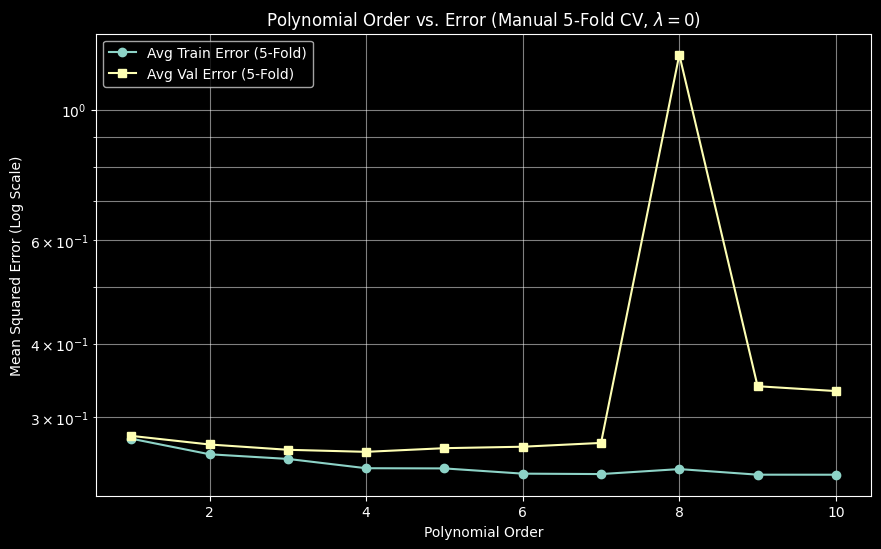

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# 1. LOAD DATA
iris = load_iris()
X_raw = iris.data[:, 0]  # Using Sepal Length as the predictor
y = iris.target          # Species as the target

# 2. MANUALLY PARTITION DATA (Train/Validation/Test)
# Requirement: Validation size == Test size
np.random.seed(42)
indices = np.arange(len(X_raw))
np.random.shuffle(indices)

n_total = len(indices)
n_test = int(0.2 * n_total)  # 20% for test (30 samples)
n_val = n_test               # 20% for final validation (30 samples)

test_idx = indices[:n_test]
val_idx = indices[n_test : n_test + n_val]
train_idx_full = indices[n_test + n_val:] # Remaining 60% (90 samples)

X_train_full, y_train_full = X_raw[train_idx_full], y[train_idx_full]
X_val_final, y_val_final = X_raw[val_idx], y[val_idx]
X_test, y_test = X_raw[test_idx], y[test_idx]

# 3. MANUAL LINEAR REGRESSION FUNCTION (Normal Equation)
def fit_manual_reg(X, y, degree, lam=0.0):
    """
    Solves theta = (XT*X + lambda*I)^-1 * XT*y
    """
    # Create the Design Matrix (Vandermonde Matrix)
    X_poly = np.column_stack([X**i for i in range(degree + 1)])

    XTX = X_poly.T @ X_poly
    XTy = X_poly.T @ y

    # Regularization Term (Ridge) - set to 0 as requested
    # We create an identity matrix but don't penalize the intercept (index 0)
    I = np.eye(XTX.shape[0])
    I[0, 0] = 0

    try:
        # Solving (XTX + lam*I) * theta = XTy
        theta = np.linalg.solve(XTX + (lam * I), XTy)
        return theta
    except np.linalg.LinAlgError:
        return None

def get_mse(X, y, theta):
    degree = len(theta) - 1
    X_poly = np.column_stack([X**i for i in range(degree + 1)])
    predictions = X_poly @ theta
    return np.mean((predictions - y)**2)

# 4. MANUAL 5-FOLD CROSS-VALIDATION
degrees = range(1, 11)
avg_train_errors = []
avg_val_errors = []
k = 5

for d in degrees:
    fold_train_errs = []
    fold_val_errs = []

    # Manual fold split of the X_train_full set
    fold_indices = np.arange(len(X_train_full))
    fold_size = len(X_train_full) // k

    for i in range(k):
        # Identify indices for this specific fold
        val_fold_idx = fold_indices[i * fold_size : (i + 1) * fold_size]
        train_fold_idx = np.setdiff1d(fold_indices, val_fold_idx)

        X_tr, y_tr = X_train_full[train_fold_idx], y_train_full[train_fold_idx]
        X_va, y_va = X_train_full[val_fold_idx], y_train_full[val_fold_idx]

        # Fit model with lambda = 0
        weights = fit_manual_reg(X_tr, y_tr, d, lam=0)

        if weights is not None:
            fold_train_errs.append(get_mse(X_tr, y_tr, weights))
            fold_val_errs.append(get_mse(X_va, y_va, weights))
        else:
            # Handle Singular Matrix by appending NaN or large error
            fold_train_errs.append(np.nan)
            fold_val_errs.append(np.nan)

    avg_train_errors.append(np.nanmean(fold_train_errs))
    avg_val_errors.append(np.nanmean(fold_val_errs))

# 5. PLOT RESULTS
plt.figure(figsize=(10, 6))
plt.plot(degrees, avg_train_errors, marker='o', label='Avg Train Error (5-Fold)')
plt.plot(degrees, avg_val_errors, marker='s', label='Avg Val Error (5-Fold)')
plt.yscale('log') # Log scale is vital because error explodes at high degrees
plt.xlabel('Polynomial Order')
plt.ylabel('Mean Squared Error (Log Scale)')
plt.title('Polynomial Order vs. Error (Manual 5-Fold CV, $\lambda=0$)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()